# LLM-Powered Automated Equity Research Assistant
**Self Project | Neela Patil**

This notebook builds an automated equity research pipeline that:
1. Fetches real financial data for any stock ticker
2. Scrapes recent news headlines
3. Computes key financial ratios and technical indicators
4. Uses an LLM (Groq/LLaMA3) to generate a structured analyst-style research report



In [1]:
import os
# ─── CONFIGURATION ───────────────────────────────────────────────────────────
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")   # set it in your environment
TICKER       = "AAPL"                      # change to any ticker: TSLA, NVDA, RELIANCE.NS etc.
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
# ─── IMPORTS ─────────────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, textwrap, json
from groq import Groq
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
print(f' Libraries loaded. Analysing: {TICKER}')

 Libraries loaded. Analysing: AAPL


## 1. Data Ingestion

In [3]:
# ─── FETCH STOCK DATA ────────────────────────────────────────────────────────
stock  = yf.Ticker(TICKER)
info   = stock.info
hist   = stock.history(period='1y')
news   = stock.news[:8]   # latest 8 headlines

company_name = info.get('longName', TICKER)
sector       = info.get('sector', 'N/A')
industry     = info.get('industry', 'N/A')
country      = info.get('country', 'N/A')

print(f'Company  : {company_name}')
print(f'Sector   : {sector} | Industry: {industry}')
print(f'Country  : {country}')
print(f'Data rows: {len(hist)} trading days fetched')

Company  : Apple Inc.
Sector   : Technology | Industry: Consumer Electronics
Country  : United States
Data rows: 252 trading days fetched


## 2. Financial Ratios & Key Metrics

In [4]:
# ─── KEY FUNDAMENTALS ────────────────────────────────────────────────────────
def safe(key, fmt=None):
    val = info.get(key, None)
    if val is None:
        return 'N/A'
    if fmt == 'pct':
        return f'{val*100:.2f}%'
    if fmt == 'B':
        return f'${val/1e9:.2f}B'
    if fmt == 'x':
        return f'{val:.2f}x'
    return str(round(val, 2))

fundamentals = {
    'Current Price'        : safe('currentPrice'),
    '52W High'             : safe('fiftyTwoWeekHigh'),
    '52W Low'              : safe('fiftyTwoWeekLow'),
    'Market Cap'           : safe('marketCap', 'B'),
    'P/E Ratio (TTM)'      : safe('trailingPE', 'x'),
    'Forward P/E'          : safe('forwardPE', 'x'),
    'P/B Ratio'            : safe('priceToBook', 'x'),
    'EV/EBITDA'            : safe('enterpriseToEbitda', 'x'),
    'Revenue (TTM)'        : safe('totalRevenue', 'B'),
    'Gross Margin'         : safe('grossMargins', 'pct'),
    'Operating Margin'     : safe('operatingMargins', 'pct'),
    'Net Profit Margin'    : safe('profitMargins', 'pct'),
    'ROE'                  : safe('returnOnEquity', 'pct'),
    'ROA'                  : safe('returnOnAssets', 'pct'),
    'Debt/Equity'          : f"{info['debtToEquity']/100:.2f}x" if info.get('debtToEquity') else 'N/A',   # Yahoo reports this as a %
    'Current Ratio'        : safe('currentRatio'),
    'Dividend Yield'       : f"{info['dividendRate']/info['currentPrice']*100:.2f}%" if info.get('dividendRate') and info.get('currentPrice') else 'N/A',
    'Beta'                 : safe('beta'),
    'Analyst Target Price' : safe('targetMeanPrice'),
    'Recommendation'       : info.get('recommendationKey', 'N/A').upper(),
}

df_fund = pd.DataFrame(fundamentals.items(), columns=['Metric', 'Value'])
display(df_fund.style.set_caption(f'{company_name} — Key Fundamentals').hide(axis='index'))

Metric,Value
Current Price,337.81
52W High,345.34
52W Low,243.42
Market Cap,$4930.13B
P/E Ratio (TTM),38.74x
Forward P/E,35.25x
P/B Ratio,45.90x
EV/EBITDA,29.38x
Revenue (TTM),$466.82B
Gross Margin,48.65%


## 3. Technical Indicators

In [5]:
# ─── TECHNICAL INDICATORS ────────────────────────────────────────────────────
df = hist.copy()

# Moving averages
df['MA_20']  = df['Close'].rolling(20).mean()
df['MA_50']  = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

# RSI (14-day)
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
rs    = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Bollinger Bands
df['BB_mid']   = df['Close'].rolling(20).mean()
df['BB_upper'] = df['BB_mid'] + 2 * df['Close'].rolling(20).std()
df['BB_lower'] = df['BB_mid'] - 2 * df['Close'].rolling(20).std()

# MACD
ema12        = df['Close'].ewm(span=12).mean()
ema26        = df['Close'].ewm(span=26).mean()
df['MACD']   = ema12 - ema26
df['Signal'] = df['MACD'].ewm(span=9).mean()

# Volatility (annualised)
df['Daily_Return'] = df['Close'].pct_change()
annual_vol = df['Daily_Return'].std() * np.sqrt(252)

latest = df.iloc[-1]
print(f"RSI (14d)          : {latest['RSI']:.1f}  {' Overbought' if latest['RSI']>70 else ' Oversold' if latest['RSI']<30 else ' Neutral'}")
print(f"Price vs MA50      : {'Above ' if latest['Close'] > latest['MA_50'] else 'Below '}")
print(f"Price vs MA200     : {'Above ' if latest['Close'] > latest['MA_200'] else 'Below '}")
print(f"MACD Signal        : {'Bullish ' if latest['MACD'] > latest['Signal'] else 'Bearish '}")
print(f"Annualised Vol     : {annual_vol*100:.1f}%")
print(f"1Y Return          : {((df['Close'].iloc[-1]/df['Close'].iloc[0])-1)*100:.1f}%")

RSI (14d)          : 52.1   Neutral
Price vs MA50      : Above 
Price vs MA200     : Above 
MACD Signal        : Bearish 
Annualised Vol     : 24.7%
1Y Return          : 31.4%


## 4. Visualisations

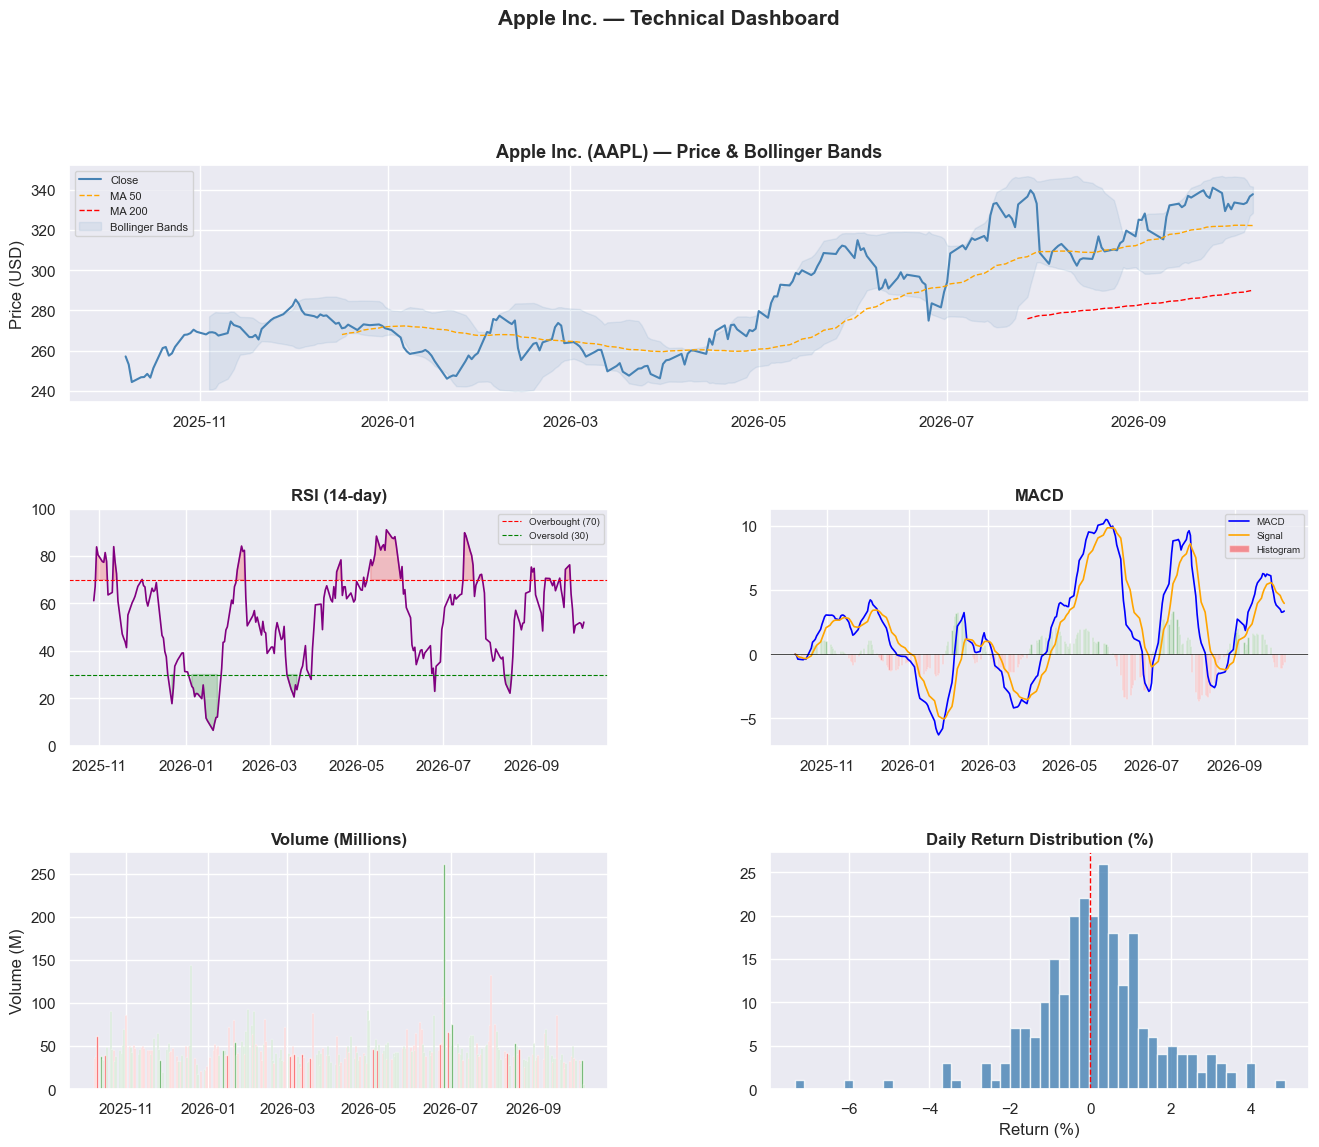

 Dashboard saved.


In [6]:
# ─── DASHBOARD PLOT ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# 1. Price + Bollinger Bands
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df['Close'],    color='steelblue', lw=1.5, label='Close')
ax1.plot(df.index, df['MA_50'],    color='orange',    lw=1,   label='MA 50',  linestyle='--')
ax1.plot(df.index, df['MA_200'],   color='red',       lw=1,   label='MA 200', linestyle='--')
ax1.fill_between(df.index, df['BB_upper'], df['BB_lower'], alpha=0.1, color='steelblue', label='Bollinger Bands')
ax1.set_title(f'{company_name} ({TICKER}) — Price & Bollinger Bands', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax1.set_ylabel('Price (USD)')

# 2. RSI
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(df.index, df['RSI'], color='purple', lw=1.2)
ax2.axhline(70, color='red',   linestyle='--', lw=0.8, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', lw=0.8, label='Oversold (30)')
ax2.fill_between(df.index, df['RSI'], 70, where=(df['RSI']>=70), alpha=0.2, color='red')
ax2.fill_between(df.index, df['RSI'], 30, where=(df['RSI']<=30), alpha=0.2, color='green')
ax2.set_title('RSI (14-day)', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=7)

# 3. MACD
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(df.index, df['MACD'],   color='blue',   lw=1.2, label='MACD')
ax3.plot(df.index, df['Signal'], color='orange', lw=1.2, label='Signal')
ax3.bar(df.index, df['MACD'] - df['Signal'],
        color=np.where(df['MACD']>df['Signal'], 'green', 'red'), alpha=0.4, label='Histogram')
ax3.axhline(0, color='black', lw=0.5)
ax3.set_title('MACD', fontweight='bold')
ax3.legend(fontsize=7)

# 4. Volume
ax4 = fig.add_subplot(gs[2, 0])
colors = ['green' if r >= 0 else 'red' for r in df['Daily_Return']]
ax4.bar(df.index, df['Volume']/1e6, color=colors, alpha=0.7)
ax4.set_title('Volume (Millions)', fontweight='bold')
ax4.set_ylabel('Volume (M)')

# 5. Return Distribution
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(df['Daily_Return'].dropna()*100, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax5.axvline(0, color='red', lw=1, linestyle='--')
ax5.set_title('Daily Return Distribution (%)', fontweight='bold')
ax5.set_xlabel('Return (%)')

plt.suptitle(f'{company_name} — Technical Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('technical_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Dashboard saved.')

## 5. News Headlines

In [7]:
# ─── RECENT NEWS ─────────────────────────────────────────────────────────────
print(f' Latest News — {company_name}\n' + '─'*60)
headlines = []
for i, article in enumerate(news, 1):
    title = article.get('content', {}).get('title', article.get('title', 'N/A'))
    headlines.append(title)
    print(f'{i}. {title}')

 Latest News — Apple Inc.
────────────────────────────────────────────────────────────


## 6. LLM-Generated Analyst Report

In [8]:
# ─── BUILD CONTEXT FOR LLM ───────────────────────────────────────────────────
tech_summary = f"""
RSI: {latest['RSI']:.1f} | MACD: {'Bullish' if latest['MACD'] > latest['Signal'] else 'Bearish'}
Price vs MA50: {'Above' if latest['Close'] > latest['MA_50'] else 'Below'}
Price vs MA200: {'Above' if latest['Close'] > latest['MA_200'] else 'Below'}
Annualised Volatility: {annual_vol*100:.1f}%
1Y Return: {((df['Close'].iloc[-1]/df['Close'].iloc[0])-1)*100:.1f}%
"""

fund_summary = "\n".join([f"{k}: {v}" for k, v in fundamentals.items()])
news_summary = "\n".join([f"- {h}" for h in headlines]) or "No recent headlines were available."

prompt = f"""
Write a structured, professional equity research report for {company_name} ({TICKER}),
dated {pd.Timestamp.today():%d %b %Y}.

FUNDAMENTALS:
{fund_summary}

TECHNICAL INDICATORS:
{tech_summary}

RECENT NEWS HEADLINES:
{news_summary}

Rules:
- Use only the data above. Do not add products, events, projects or numbers from your own
  knowledge; if something isn't covered by the data, leave it out.
- Do not include an author line, firm name, or placeholder text in square brackets.
- Make the recommendation consistent with your 12-month price target: BUY only if the target is
  at least 10% above the current price, SELL if at least 10% below, otherwise HOLD.
- If no headlines were available, say so in one line instead of guessing at news.

Structure the report with these exact sections:
1. **Executive Summary** (3-4 sentences, include the BUY/HOLD/SELL recommendation)
2. **Business Overview** (sector, business model, competitive position)
3. **Fundamental Analysis** (valuation multiples, margins, balance sheet health)
4. **Technical Analysis** (price trend, momentum, support/resistance)
5. **Key Risks** (3-4 specific risks)
6. **Investment Thesis** (bull case, bear case, and 12-month price target rationale)

Be specific and data-driven, and use the actual numbers provided.
"""

print(' Prompt built. Sending to LLM...')

 Prompt built. Sending to LLM...


In [9]:
# ─── CALL GROQ LLM ───────────────────────────────────────────────────────────
client = Groq(api_key=GROQ_API_KEY)

response = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[
        {"role": "system", "content": "You are a senior equity research analyst. Write detailed, data-driven reports."},
        {"role": "user",   "content": prompt}
    ],
    temperature=0.3,
    max_completion_tokens=4000,
    reasoning_effort="low"
)

report = response.choices[0].message.content

display(Markdown(f"#  Equity Research Report — {company_name} ({TICKER})"))
display(Markdown(report))

#  Equity Research Report — Apple Inc. (AAPL)

**Apple Inc. (AAPL) – Equity Research Report**  
*Date: 08 Oct 2026*  

---

### 1. Executive Summary  
Apple trades at $337.81, near its 52‑week high of $345.34 and well above its 52‑week low of $243.42. Valuation metrics (P/E 38.74x, Forward P/E 35.25x) remain elevated relative to historical averages, while the consensus 12‑month target of $328.09 implies a modest downside of roughly 3 %. Given the target is less than 10 % below the current price, the recommendation is **HOLD**. The stock’s strong profitability and cash generation are offset by a high price multiple and limited upside in the near term.

### 2. Business Overview  
- **Sector:** Technology – Consumer Electronics & Services.  
- **Business Model:** Integrated hardware, software, and services ecosystem generating recurring revenue streams from device sales, App Store, cloud services, and wearables.  
- **Competitive Position:** Market‑leading brand with a dominant share in premium smartphones, tablets, and wearables; high switching costs and a robust services platform reinforce pricing power.

### 3. Fundamental Analysis  
| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Market Cap** | $4,930.13 B | Among the world’s largest public companies. |
| **P/E (TTM)** | 38.74x | Significantly above the historical average for mature tech firms, indicating premium pricing. |
| **Forward P/E** | 35.25x | Slightly lower forward multiple suggests modest earnings growth expectations. |
| **P/B** | 45.90x | Reflects strong intangible asset base; high relative to peers. |
| **EV/EBITDA** | 29.38x | Consistent with high‑growth tech valuations. |
| **Revenue (TTM)** | $466.82 B | Robust top‑line size, supporting scale advantages. |
| **Gross Margin** | 48.65% | Healthy margin reflecting premium pricing and efficient supply chain. |
| **Operating Margin** | 32.62% | Strong operating efficiency. |
| **Net Profit Margin** | 27.62% | High profitability relative to peers. |
| **ROE** | 148.75% | Extremely high, driven by large equity base and share buybacks. |
| **ROA** | 27.08% | Strong asset efficiency. |
| **Debt/Equity** | 0.78x | Moderate leverage; balance sheet remains solid. |
| **Current Ratio** | 1.0 | Adequate short‑term liquidity. |
| **Dividend Yield** | 0.32% | Low yield, reflecting focus on reinvestment and share repurchases. |
| **Beta** | 1.07 | Slightly more volatile than the market. |

Overall, Apple exhibits superior profitability and return metrics, but its valuation multiples are elevated, limiting near‑term upside.

### 4. Technical Analysis  
- **Price Trend:** Current price ($337.81) sits above both the 50‑day and 200‑day moving averages, indicating a bullish short‑ and medium‑term trend.  
- **Momentum:** RSI at 52.1 signals a neutral stance—neither overbought nor oversold. The MACD shows a bearish divergence, suggesting potential short‑term weakness.  
- **Volatility:** Annualised volatility of 24.7% is typical for high‑cap tech stocks.  
- **Support/Resistance:** Immediate support lies near the 200‑day MA (~$320) and the 52‑week low ($243.42) is far below current levels. Resistance is anchored by the 52‑week high at $345.34 and the 50‑day MA (~$335). A break below $320 could open the path toward the lower end of the 52‑week range, while a sustained rally above $345 could trigger a retest of prior highs.

### 5. Key Risks  
1. **Valuation Compression:** High P/E and EV/EBITDA ratios leave limited room for earnings growth before the stock becomes overvalued, increasing the risk of multiple contraction.  
2. **Macroeconomic Sensitivity:** A 10 %+ decline in consumer discretionary spending could pressure device sales, affecting revenue growth.  
3. **Regulatory Exposure:** Ongoing antitrust scrutiny in major markets could lead to fines or operational constraints on the App Store ecosystem.  
4. **Supply‑Chain Constraints:** Dependence on a limited set of component suppliers could disrupt production if geopolitical tensions intensify.

### 6. Investment Thesis  

**Bull Case:**  
- Continued expansion of high‑margin services (cloud, subscription) drives earnings growth, narrowing the gap between forward earnings and current valuation.  
- Strong brand loyalty sustains premium pricing, preserving gross and operating margins.  
- Share repurchases and modest dividend maintain shareholder returns, supporting the stock price.

**Bear Case:**  
- Elevated valuation multiples compress if earnings growth stalls, leading to a price correction toward the consensus target of $328.09.  
- MACD bearish signal and potential macro‑economic headwinds could trigger a pullback below key support (~$320).  
- Regulatory actions could erode the lucrative services revenue stream.

**12‑Month Price Target Rationale:**  
The consensus target of $328.09 reflects a modest discount to the current price, incorporating expectations of stable earnings growth but acknowledging valuation pressure and the bearish MACD signal. Given the target is less than 10 % below the current level, the recommendation is **HOLD**—the stock offers limited upside while maintaining strong fundamentals, but the premium valuation warrants caution.

In [10]:
# ─── SAVE REPORT ─────────────────────────────────────────────────────────────
with open(f'{TICKER}_research_report.md', 'w') as f:
    f.write(f'# Equity Research Report — {company_name} ({TICKER})\n\n')
    f.write(report)

print(f' Report saved as {TICKER}_research_report.md')

 Report saved as AAPL_research_report.md


## 7. Multi-Stock Comparison

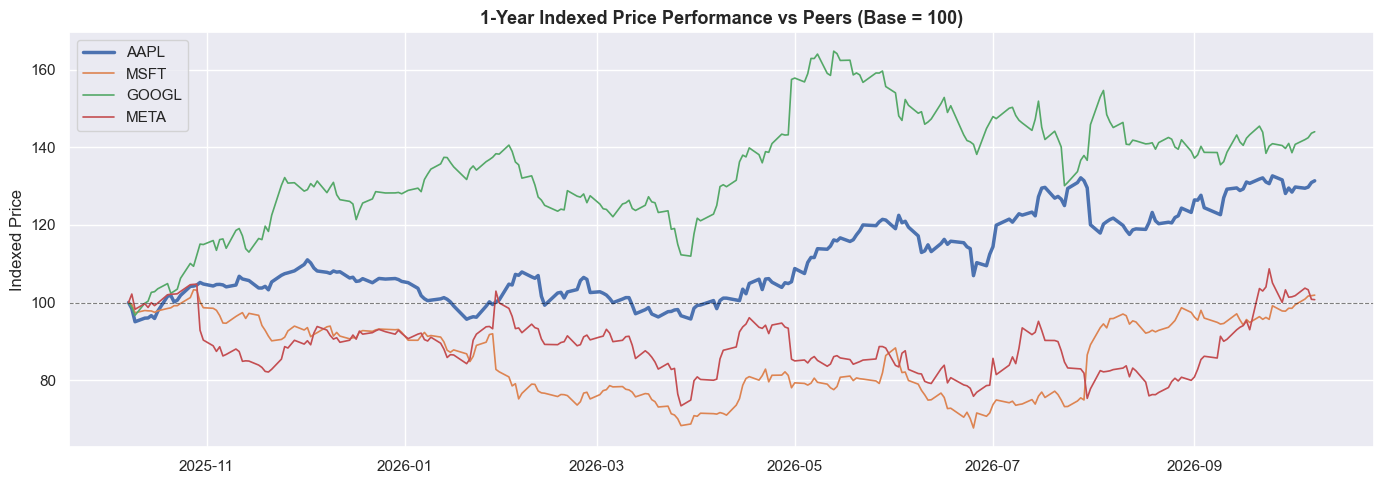

In [11]:
# ─── COMPARE AGAINST PEERS ───────────────────────────────────────────────────
PEERS = [TICKER, 'MSFT', 'GOOGL', 'META']

peer_data = {}
for t in PEERS:
    try:
        h = yf.Ticker(t).history(period='1y')['Close']
        peer_data[t] = (h / h.iloc[0]) * 100   # normalise to 100
    except:
        pass

df_peers = pd.DataFrame(peer_data)

fig, ax = plt.subplots(figsize=(14, 5))
for col in df_peers.columns:
    lw = 2.5 if col == TICKER else 1.2
    ax.plot(df_peers.index, df_peers[col], label=col, lw=lw)

ax.axhline(100, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax.set_title('1-Year Indexed Price Performance vs Peers (Base = 100)', fontsize=13, fontweight='bold')
ax.set_ylabel('Indexed Price')
ax.legend()
plt.tight_layout()
plt.savefig('peer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
